Goal: Convolutional GAN. Most of GAN engineering is in the architecture choices.
Tasks:
- G: latent → reshape → stack of ConvTranspose2d with BatchNorm + ReLU, final Tanh.
- D: stack of Conv2d with BatchNorm + LeakyReLU(0.2), final 1x1 conv to scalar.
- Data normalized to [-1, 1] (matches Tanh output).
- Adam with lr=2e-4, β1=0.5, β2=0.999 — the canonical settings.
- Initialize weights from N(0, 0.02) per the paper.

Concepts: Strided convolutions vs pooling, BN role in stabilizing GANs, why LeakyReLU in D.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image
# from torchview import draw_graph


In [2]:
from torchvision import datasets
from torch.utils.data import DataLoader
import torchvision

# Normalize MNIST to [-1, 1] so it matches Tanh output range.
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,0.5, 0.5), std=(0.5,0.5,0.5)),
])
train_ds = datasets.CIFAR10('./cifar', train=True, download=True, transform=transform)
# train_ds.data = train_ds.data[:1600]
train_dl = DataLoader(
    train_ds, batch_size=32, shuffle=True,
    num_workers=2, drop_last=True, pin_memory=True,
)

Files already downloaded and verified


In [3]:
from typing import Any
class Generator(nn.Module):
    def __init__(self, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)
        
        self.net = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels=100, 
                out_channels=1024, 
                kernel_size=4, 
                # padding=1,
                stride = 1, 
                padding = 0,
            ), # output shape - 1024 x 4 x 4
            nn.BatchNorm2d(1024,momentum=0.5), 
            nn.ReLU(),        
            nn.ConvTranspose2d(
                in_channels=1024, 
                out_channels=512, 
                kernel_size=4, 
                padding=1,
                stride=2, 
            ), # output shape - 512 x 8 x 8
            nn.BatchNorm2d(512,momentum=0.5), 
            nn.ReLU(),        
            nn.ConvTranspose2d(
                in_channels=512, 
                out_channels=256, 
                kernel_size=4, 
                padding=1,
                stride=2, 
            ), # output shape - 256 x 16 x 16
            nn.BatchNorm2d(256,momentum=0.5), 
            nn.ReLU(), 
            # H_OUT = (H_IN - 1) * stride - 2 x padding + dialation x (kernel_size - 1) + output_padding   + 1
            nn.ConvTranspose2d(
                in_channels=256, 
                out_channels=128, 
                kernel_size=4, 
                padding=1,
                stride=2, 
            ), # output shape - 128 x 32 x 32
            nn.BatchNorm2d(128,momentum=0.5), 
            nn.ReLU(),    
            # H_OUT = (H_IN - 1) * stride - 2 x padding + dialation x (kernel_size - 1) + output_padding   + 1
            nn.ConvTranspose2d(
                in_channels=128, 
                out_channels=3, 
                kernel_size=4, 
                padding=1,
                stride=2, 
            ), # output shape - 3 x 64 x 64
            nn.Tanh(),
        )
    def forward(self, x: torch.Tensor):
        # x - [B, N] - n = 100
        # reshape given noise to 100 x 1 x 1
        x = x.unsqueeze(-1).unsqueeze(-1)
        return self.net(x)
    
    
class Discriminator(nn.Module):
    def __init__(self, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)
        self.net = nn.Sequential(
            nn.Conv2d(
                in_channels=3, 
                out_channels=64,
                kernel_size=4,
                padding=1,
                stride=2, bias=False
            
            ), 
            nn.BatchNorm2d(64,momentum=0.5), 
            nn.LeakyReLU(),
            nn.Conv2d(
                in_channels=64, 
                out_channels=128,
                kernel_size=4,
                padding=1,
                stride=2, bias=False
            
            ), 
            nn.BatchNorm2d(128,momentum=0.5), 
            nn.LeakyReLU(),
            nn.Conv2d(
                in_channels=128, 
                out_channels=256,
                kernel_size=4,
                padding=1,
                stride=2, bias=False
            
            ), 
            nn.BatchNorm2d(256,momentum=0.5), 
            nn.LeakyReLU(),
            nn.Conv2d(
                in_channels=256, 
                out_channels=512,
                kernel_size=4,
                padding=1,
                stride=2, bias=False
            
            ), 
            nn.BatchNorm2d(512,momentum=0.5), 
            nn.LeakyReLU(),
            nn.Conv2d(
                in_channels=512, 
                out_channels=1,
                kernel_size=4,
                padding=0,
                stride=1, bias=False
            )
        )
        
    def forward(self, x: torch.Tensor):
        return self.net(x).view(-1)
    
random_noise = torch.rand([8, 100])
G = Generator()
D = Discriminator()

# generator_graph = draw_graph(
#     G, 
#     input_size=random_noise.shape, 
#     expand_nested=True
# )
# discriminator_graph = draw_graph(
#     D, 
#     input_size=[8, 3,64,64], 
#     expand_nested=True
# )

In [4]:
# discriminator_graph.visual_graph

In [5]:
# generator_graph.visual_graph

# Training

In [6]:
from tqdm import tqdm

N_EPOCHS, LATENT_DIM = 50, 100
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
G, D = Generator().to(DEVICE), Discriminator().to(DEVICE)
# G.apply(weights_init)
# D.apply(weights_init)

opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce   = nn.BCEWithLogitsLoss()

fixed_z = torch.randn(64, LATENT_DIM, device=DEVICE)

losses = []

for epoch in range(N_EPOCHS):
    
    epoch_losses = []
    
    train_iter = tqdm(enumerate(train_dl), total=len(train_dl), desc=f"Epoch {epoch+1}/{N_EPOCHS}")
    for step, (real, _) in train_iter:
        real = real.to(DEVICE)
        B = real.size(0)
        ones, zeros = torch.ones(B, device=DEVICE), torch.zeros(B, device=DEVICE)

        # --- D step ---
        opt_D.zero_grad(set_to_none=True)
        d_real = D(real)
        z = torch.randn(B, LATENT_DIM, device=DEVICE)
        fake = G(z)
        d_fake = D(fake.detach())
        loss_d = bce(d_real, ones) + bce(d_fake, zeros)
        loss_d.backward(); opt_D.step()

        # --- G step ---
        opt_G.zero_grad(set_to_none=True)
        loss_g = bce(D(fake), ones)   # non-saturating
        loss_g.backward(); opt_G.step()
        
        epoch_losses.append([loss_g.item(), loss_d.item()])

        if step % 100 == 0:
            train_iter.set_postfix({
                "D_loss": f"{loss_d.item():.3f}",
                "G_loss": f"{loss_g.item():.3f}",
                "D(x)": f"{torch.sigmoid(d_real).mean():.3f}",
                "D(G(z))": f"{torch.sigmoid(d_fake).mean():.3f}"
            })
            
    losses.append(
        epoch_losses
    )

    G.eval()
    with torch.no_grad():
        save_image(G(fixed_z), f'samples_dcgan/epoch_{epoch:03d}.png',
                   nrow=8, normalize=True, value_range=(-1, 1))
    G.train()

Epoch 50/50: 100%|██████████| 1562/1562 [00:42<00:00, 36.46it/s, D_loss=0.028, G_loss=6.754, D(x)=0.999, D(G(z))=0.024]


References:
 - Radford et al. 2016: Unsupervised Representation Learning with DCGANs — Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks
 - PyTorch DCGAN tutorial (reference implementation): DCGAN Tutorial — PyTorch Tutorials 2.12.0+cu130 documentation

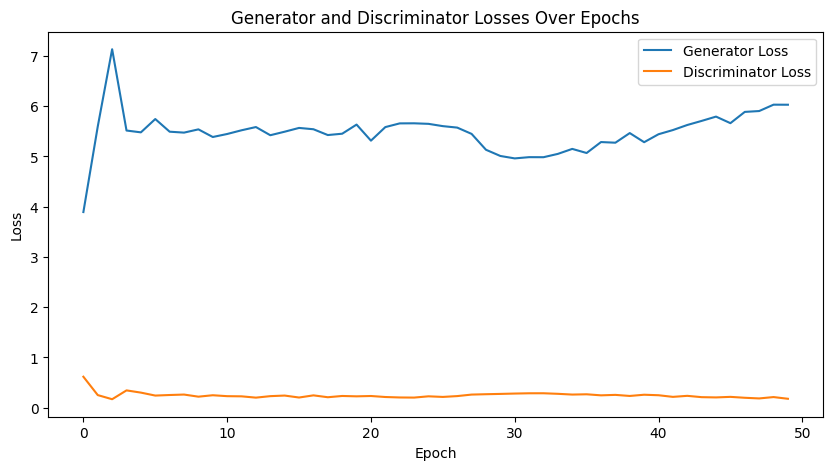

In [9]:
from matplotlib import pyplot as plt

# Plot generator and discriminator losses per epoch
g_losses = [sum([step[0] for step in epoch]) / len(epoch) for epoch in losses]
d_losses = [sum([step[1] for step in epoch]) / len(epoch) for epoch in losses]

plt.figure(figsize=(10, 5))
plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator and Discriminator Losses Over Epochs")
plt.legend()
plt.show()